# Notebook: Basic use of SeismoStats
<div class="alert alert-block alert-info">

This notebook is a manual for the SeismoStats package. It is intended to be used as a reference for the basic functionality. All examples are given using the Swiss national catalog for the year 2024.

 In this notebook we will show how to:
<ol>
    <li> Make a catalog object
    <li>Visualisations</li>
    <ol>
        <li>Spatial plot of the seismicity</li>
        <li>Temporal plot of the seismicity</li>
        <li>Frequency-magnitude distribution plots</li>
    </ol>
    <li>Statistical analysis of the catalog</li>
    <ol>
        <li>Estimation of the magnitude of completeness</li> 
        <li>Estimation of the b-value</li> 
    </ol>
    <li> Advanced statistical analysis</li>
    <ol>
        <li>Stability of b-value over magnitudes of completeness</li>
        <li>Statistical significance of b-value variations</li>
    </ol>
    <li>Generate synthetic catalogs</li>
</ol>

</div>

## 0 Import general packages

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

## 1 Creating a catalog object

<div class="alert alert-block alert-warning">
<font color=#208de2>     
The catalog object is a pandas.DataFrame, where each row represents a single event. A catalog object also comes with  attributes for metadata and methods for visualization and statistical analysis.

The columns typically contain information such as origin time, magnitude, and event location. At a minimum, a Catalog object must include a magnitude column. Common additional data columns include, but are not limited to:
* time (pandas timestamp)
* latitude (float)
* longitude (float)
* depth (float)
* event_type (string)
* mag_type (string)

</font>
</div>

### 1.1 Download a catalog from a web service

In [5]:
from seismostats import FDSNWSEventClient
from seismostats import Catalog

<font color=#208de2> Start date and end date have to be defined as a datetime. In case something does not work out, the link to retrieve it manually is given back. </font>

In [6]:
data = pd.read_csv(
    '/Users/chouyuhin/_Harvard/b-value/b_value/experiments/3tibet/region3_tibet.csv',
    sep=',',
    usecols=['year', 'month', 'day', 'hour', 'minute', 'second','latitude', 'longitude','depth', 'mag_type', 'magnitude']
    # delim_whitespace=True,
    # usecols=['lat', 'lon', 'depth', 'year', 'month', 'day', 'hour', 'minute', 'second', 'magnitude']
)

data['time'] = pd.to_datetime(data[['year', 'month', 'day', 'hour', 'minute', 'second']])
# data = data[data['time']>='2006-01-01 00:00:00']
# data = data[data['time']<='1980-12-31 23:59:59']

data = data[['longitude', 'latitude', 'depth', 'time', 'magnitude']]
# print(data.isnull().sum())
cat = Catalog(data)

# cat
cat.tail()

,longitude,latitude,depth,time,magnitude
238120,80.530,42.192,16,2023-08-13 20:45:49.470,2.44072
238121,86.982,43.928,16,2023-08-13 21:06:42.930,1.83270
238122,76.888,36.735,82,2023-08-13 21:38:26.630,2.44072
238123,85.451,42.788,17,2023-08-13 22:53:45.110,1.65898
238124,83.560,36.856,16,2023-08-13 23:00:47.860,1.31154


<font color=#208de2> The output is a catalog object</font>

## 2 Seismicity Plots

<div class="alert alert-block alert-warning">
<font color=#208de2>     
The SeismoStats package provides methods to visualize:

<ol>
<li>Seismicity in space</li>
<li>Seismicity in time</li> 
<li>The distribution of magnitudes</li> 
</ol>

</font>
</div>

### 2.1 Spatial visualization of seismicity

### 2.2 Temporal visualization of seismicity 

#### 2.2.1 Cumulative count of events over time
This plot shows the cumulative count of events over time above specific magnitude thresholds. 

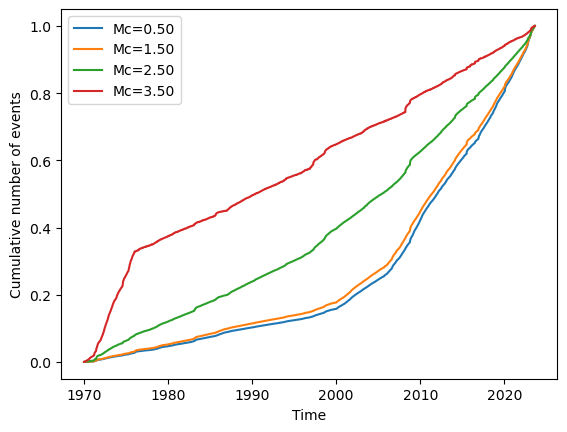

In [5]:
# Define target magnitudes starting at 0.5 and going up to 4.0 in steps of 1.0 magnitude units
target_magnitudes = np.arange(0.5, 4.0, 1.0) 

ax = cat.plot_cum_count(mcs=target_magnitudes)

#### 2.2.2 Timeline of magnitudes 
This plot shows the earthquakes' magnitudes over time. By default the events all have the same color, but you can specify a color gradient based (for example) on the time of the event by specifying `color_dots` as a numpy array.

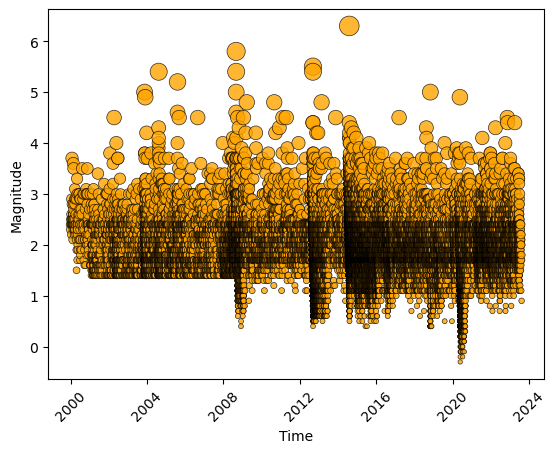

In [16]:
# Basic version without coloring
ax = cat.plot_mags_in_time(color_dots='orange')

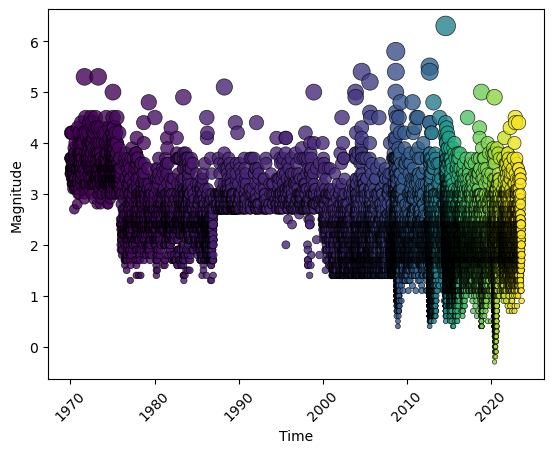

In [6]:
# Coloring events by time
ax = cat.plot_mags_in_time(color_dots=np.arange(len(cat)))
# plt.savefig('longmenshan_MT.pdf', dpi=300)

## 3 Frequency-Magnitude Distributions (FMD) and statistical analysis of the catalog
FMD is a histogram-style plot that shows the number of earthquakes per magnitude bin.

### 3.1 Plot the FMD

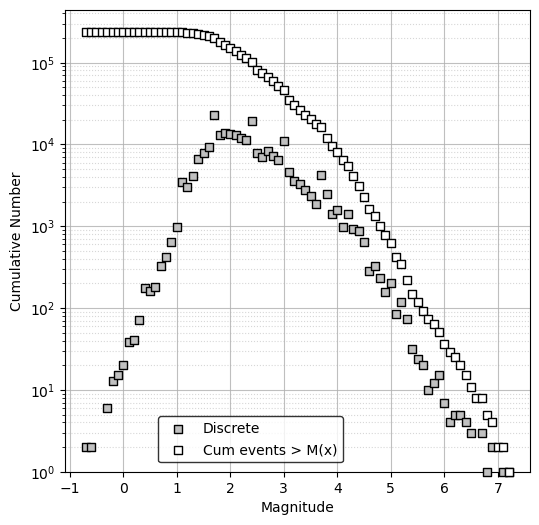

In [7]:
# It is *highly* recommended to bin magnitudes to the catalogue precision before plotting
cat.bin_magnitudes(delta_m=0.1, inplace=True)

# Plot FMD
ax = plt.subplots(figsize=(6, 6))[1]


# non-cumulative frequency-magnitude distribution with different bin sizes
cat.plot_fmd(fmd_bin=0.1, ax=ax, label="Discrete")
# cumulative frequency-magnitude distribution
cat.plot_cum_fmd(fmd_bin=0.1, ax=ax, grid=True)

plt.show()

### 3.2 Estimate the magnitude of completeness
Currently, SeismoStats supports three methods to estimate the magnitude of completeness:
<ol> 
<li>Maximum Curvature (MAXC)</li>
<li>Mc by b-value stability (MBS)</li>
<li>K-S distance (KS)</li>
</ol>

In [8]:
# Maximum Curvature (MAXC)

# For this method a magnitude discretisation has to be selected by the user with `fmd_bin`. 
# This binning might be different from the binning of the catalog; the optimal value depends on the data. 
mc_maxc, _= cat.estimate_mc_maxc(fmd_bin=0.1)

# By using the a method to estimate the magnitude of completeness, the catalog is automatically updated with the estimated Mc value.
print(f'Estimated Mc using MAXC: {mc_maxc}')
print(f'Mc (currently set catalog attribute): {cat.mc}')

Estimated Mc using MAXC: 1.9
Mc (currently set catalog attribute): 1.9


In [10]:
# Mc by b-value stability (MBS)
mc_stab, _ = cat.estimate_mc_b_stability(stop_when_passed=True)

print(f'Estimated Mc using MBS: {mc_stab}')
# The catalog is automatically updated with the newly estimated Mc value:
print(f'Mc (currently set catalog attribute): {cat.mc}')

return_vals: {'best_b_value': 1.1227982955642708, 'mcs_tested': [-0.3, -0.2, -0.1, 0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7], 'b_values_tested': [0.2020685793769687, 0.211924542233833, 0.22278344521581966, 0.23481491869437177, 0.24820433389752228, 0.2632058133204325, 0.2801199368155674, 0.2993158624535603, 0.32068945306600455, 0.34524296246207575, 0.3733392658007934, 0.405233458082519, 0.4413331900274887, 0.4815584280097413, 0.5260221849272559, 0.5486021450064912, 0.5902516853975766, 0.6345946011992363, 0.6780762487453009, 0.7226351277221733, 0.7710528812674207, 0.7166988155607633, 0.7424571711804068, 0.7707678360474944, 0.801014543328221, 0.8355196348681284, 0.8799951888799923, 0.9098039560865779, 0.7911185448861258, 0.8016697163195732, 0.8266322287899847, 0.8463602818786686, 0.8726214136298742, 0.9040046490424777, 0.8131000210013524, 0.83

In [44]:
# K-S distance (KS)
# This method takes longer, especially when the catalog is large. 
# If Mc is known to be larger than a certain value, giving the Mc values that should be tested as an input can make the Mc estimation faster.

mc_kstest, dict = cat.estimate_mc_ks(
   mcs_test=np.arange(1.0, 3.0, 0.1), # range of Mc values to test with steps of 0.1
    p_value_pass=0.1, # p-value threshold to pass the K-S test 
) 

print(f"First Mc to pass the KS test: {mc_kstest:.2f}")
print(f"Associated beta value: {dict['best_b_value']:.2f}")

# The catalog is automatically updated with the newly estimated Mc value:
print(f'Mc (currently set catalog attribute): {cat.mc:.2f}')

TypeError: unsupported format string passed to NoneType.__format__

Legend added to the plot.


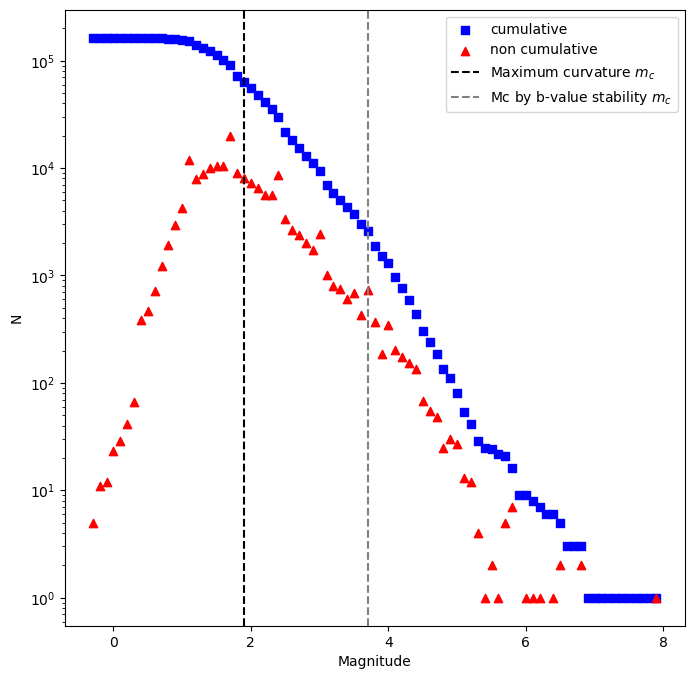

In [11]:
# Plot the FMD with the estimated Mc value
ax = plt.subplots(figsize=(8, 8))[1]

cat.plot_cum_fmd(fmd_bin=0.1, ax=ax, color='blue')
cat.plot_fmd(fmd_bin=0.1, ax=ax, color='red')

plt.axvline(mc_maxc, color='black', linestyle='--', label='Maximum curvature $m_c$')
plt.axvline(mc_stab, color='grey', linestyle='--', label='Mc by b-value stability $m_c$')
# plt.axvline(mc_kstest, color='lightgrey', linestyle='--', label='KS-test $m_c$')

plt.legend()
plt.show()

### 3.3 Estimate the b-value
SeismoStats supports different methods to estimate the b-value:
<ol> 
<li>Classical b-value</li>
<li>K-S distance (KS)</li>
<li>Mc by b-value stability (MBS)</li>
</ol>

Note that the Mc set last will be used for the b-value estimation (in this case KS-test).

#### 3.3.1 Classical b-value estimation

In [9]:
b_estimator = cat.estimate_b(mc=mc_maxc)
b_classical = b_estimator.b_value
b_classical_std = b_estimator.std
# The calculated b-value is stored in cat.b_value, but the estimator object contains more information:
print('Classical b-value', round(b_classical,3))
print('Standard deviation', round(b_classical_std,2))
print('Number of events used', b_estimator.n)

Classical b-value 0.543
Standard deviation 0.0
Number of events used 164536


Legend added to the plot.


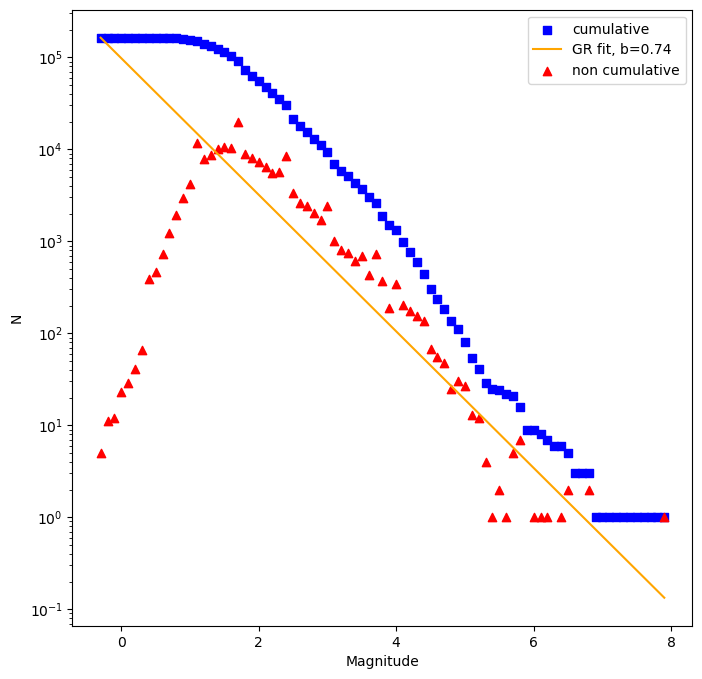

In [49]:
# FMD plot with b-value
# Once a b-value is estimated and stored in cat.b_value, the FMD can be plotted with a fit:
ax = plt.subplots(figsize=(8, 8))[1]
cat.plot_cum_fmd(color='blue',ax=ax, color_line = 'orange')
cat.plot_fmd(fmd_bin=0.1, ax=ax, color='red')

# plt.axvline(mc_kstest, color='lightgrey', linestyle='--', label='KS-test $m_c$')
plt.legend()
plt.show()

#### 3.3.2 b-positive

In [10]:
from seismostats.analysis import BPositiveBValueEstimator
b_estimator = cat.estimate_b(mc=mc_maxc,method =BPositiveBValueEstimator)
b_positive = b_estimator.b_value
b_positive_std = b_estimator.std
print("b-positive:",round(b_positive,2))
print("std:",round(b_positive_std,2))

b-positive: 0.86
std: 0.0


## 4 Advanced statistical analysis of the catalogue

### 4.1 b-value stability

<AxesSubplot:xlabel='Completeness magnitude $m_c$', ylabel='b-value'>

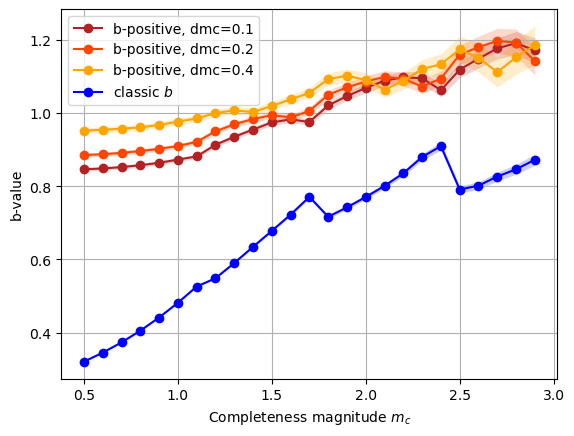

In [51]:
# b-value for different mangitudes of completeness
from seismostats.analysis import ClassicBValueEstimator, BPositiveBValueEstimator

mcs = np.arange(0.5, 3, 0.1)
ax = cat.plot_mc_vs_b(mcs, b_method=BPositiveBValueEstimator, dmc=0.1, color='firebrick', label='b-positive, dmc=0.1')
cat.plot_mc_vs_b(mcs, b_method=BPositiveBValueEstimator, dmc=0.2, ax=ax,  color='orangered', label='b-positive, dmc=0.2')
cat.plot_mc_vs_b(mcs, b_method=BPositiveBValueEstimator, dmc=0.4, ax=ax,  color='orange', label='b-positive, dmc=0.4')

cat.plot_mc_vs_b(mcs, b_method=ClassicBValueEstimator, ax =ax, color='blue', label='classic $b$')

#### 4.2 Timeseries of b-values
Plotting the evolution of b-values (classic and positive) over time can help identify changes in seismicity patterns. One can also investigate if the variation of the b-value is larger than what one would expect just from random fluctuation of the estimate and reject a null-hypothesis of b-value being constant over time using the mean autocorrelation (see Mirwald et al., 2024).

0.1


Text(0.5, 0, 'Time')

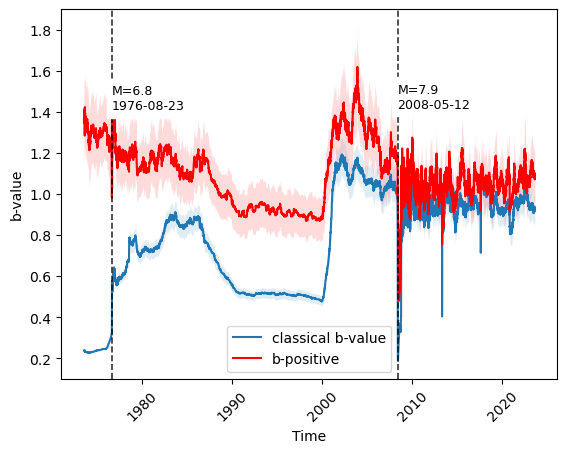

In [54]:
from seismostats.analysis import b_significant_1D
from seismostats.plots import plot_b_series_constant_nm, plot_b_significant_1D

# Parameter setting for the b-value series
mc = mc_maxc # chosen magnitude of completeness
delta_m = cat.delta_m # binning of the magnitudes
print(delta_m)
times = cat.time 
mags = cat.magnitude
n_m = 500 # number of magnitudes taken per estimate in the running window (above completeness)

ax = plot_b_series_constant_nm(mags, delta_m, mc, times, n_m=n_m, x_variable=times, color='#1f77b4', plot_technique='right', label='classical b-value')

ax = plot_b_series_constant_nm(mags, delta_m, mc, times, n_m=n_m, x_variable=times, color='red', plot_technique='right', label='b-positive', ax=ax, method=BPositiveBValueEstimator)

# 找出震级最大的前3个事件
top_n = 2
top_indices = np.argsort(mags.values)[-top_n:]  # ✅ 用 .values，确保得到纯 numpy 索引

# 循环画出前3大地震
for i in reversed(top_indices):
    event_time = times.iloc[i]   # ✅ 按位置取时间
    event_mag = mags.iloc[i]     # ✅ 按位置取震级
    date_str = event_time.strftime('%Y-%m-%d')

    ax.axvline(
        x=event_time,
        color='black',
        linestyle='--',
        linewidth=1.2,
        alpha=0.8
    )

    ax.text(
        event_time,
        ax.get_ylim()[1] * (0.75 + 0.05 * np.random.rand()),  # 高度略随机，防重叠
        f'M={event_mag:.1f}\n{date_str}',
        rotation=0,
        va='center',
        ha='left',
        color='black',
        fontsize=9,
        backgroundcolor='white'
    )

_ = plt.xticks(rotation=45)
ax.set_xlabel('Time')

In [13]:
from seismostats.analysis import b_significant_1D
# Is the b-value calculated with 100 events above completeness constant over time?
p_threshold = 0.05
mc = mc_maxc # chosen magnitude of completeness
delta_m = cat.delta_m # binning of the magnitudes
times = cat.time 
mags = cat.magnitude
p, mac, mu_mac, std_mac = b_significant_1D(mags, mc, delta_m, times, 6000, x_variable=times, method= BPositiveBValueEstimator)
print('The p-value of a constant b-value hypothesis is {:.2f}'.format(p))

print('This is significantly larger than our threshold of {:.2f}. Therefore, we cannot reject the null-hypothesis'.format(p_threshold))


The p-value of a constant b-value hypothesis is 0.10
This is significantly larger than our threshold of 0.05. Therefore, we cannot reject the null-hypothesis


<AxesSubplot:xlabel='$n_m$', ylabel='MAC'>

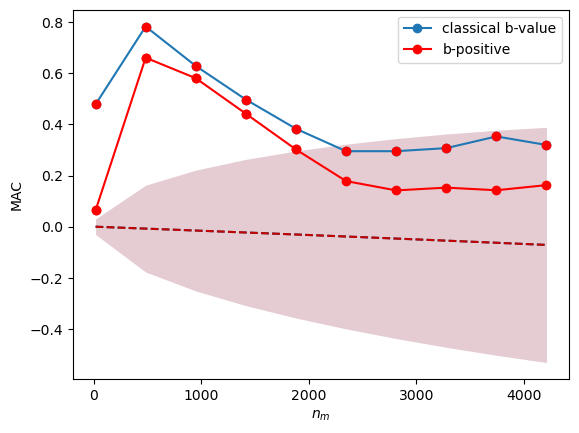

In [56]:
# sort magnitudes along dimension of interest (in this case, time)
srt = np.argsort(times)
mags = mags[srt]
times = times[srt]

ax = plot_b_significant_1D(
    mags, mc, delta_m, times, x_variable=times, color = '#1f77b4', label='classical b-value')

plot_b_significant_1D(
    mags, mc, delta_m,  times, x_variable=times, method=BPositiveBValueEstimator, color = 'red', ax = ax, label='b-positive')


## 4.4 画到一个图里

/Users/chouyuhin/miniconda3/envs/seismo/lib/python3.10/site-packages/seismostats/analysis/bvalue/base.py:119: UserWarning: No magnitudes in the lowest magnitude bin are present.Check if mc is chosen correctly.
  warnings.warn(


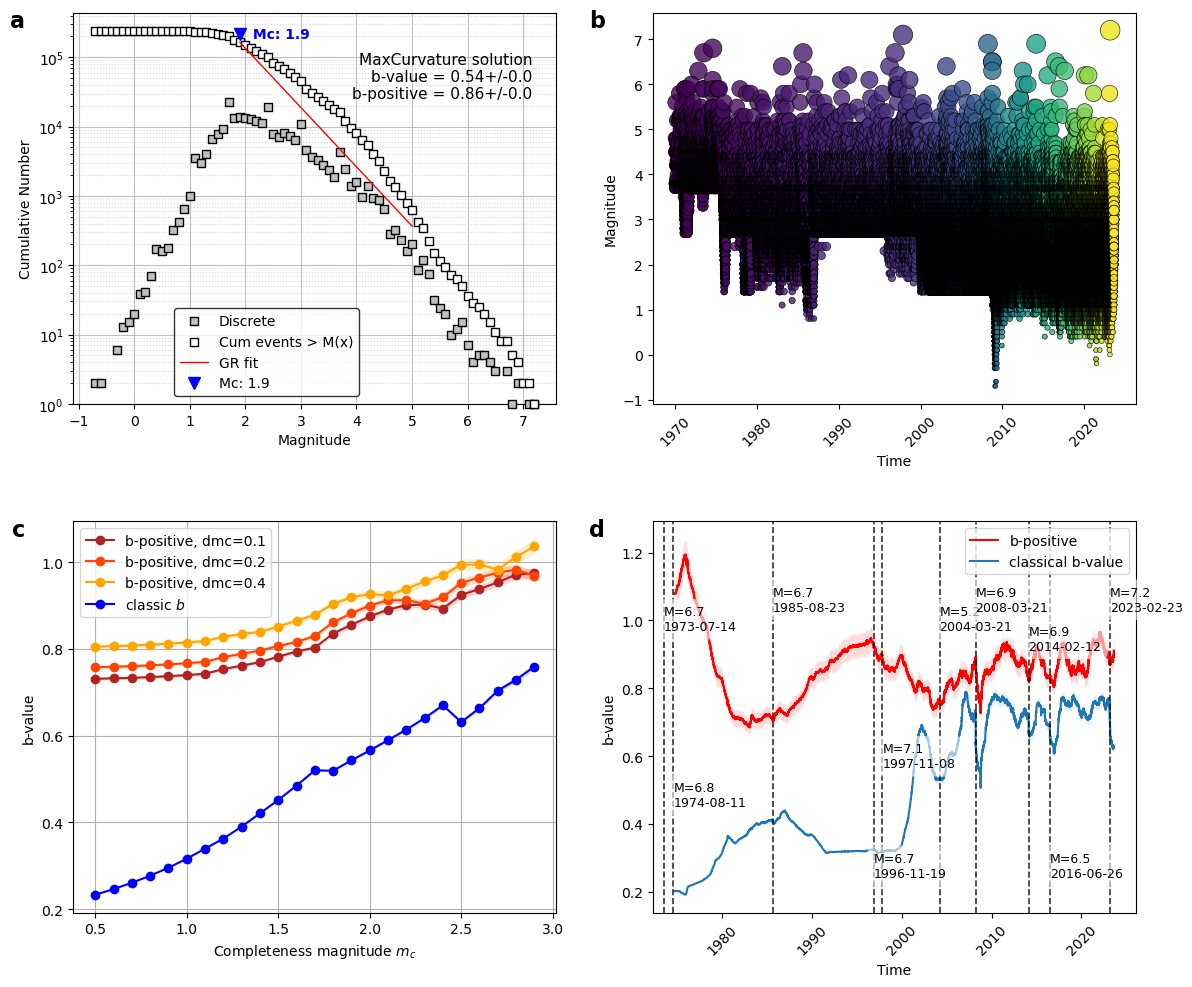

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from seismostats.analysis import ClassicBValueEstimator, BPositiveBValueEstimator, b_significant_1D
from seismostats.plots import plot_b_series_constant_nm, plot_b_significant_1D

# 1. 创建 2x2 的画布
# figsize 可以根据需要调整，例如 (14, 10)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 2. 处理第一个子图的位置 (左上角 axes[0, 0])
# 根据你的要求，这个位置空出来
ax_fmd = axes[0, 0] # 关闭坐标轴显示
cat.bin_magnitudes(delta_m=0.1, inplace=True)



# non-cumulative frequency-magnitude distribution with different bin sizes
cat.plot_fmd(fmd_bin=0.1, ax=ax_fmd, label="Discrete")
# cumulative frequency-magnitude distribution
cat.plot_cum_fmd(fmd_bin=0.1, ax=ax_fmd, grid=True)
b_val = round(b_classical,2)
b_std = round(b_classical_std,2)
b_positive_val = round(b_positive,2)
b_positive_std = round(b_positive_std,2)
stats_text = f"MaxCurvature solution\nb-value = {b_val}+/-{b_std}\nb-positive = {b_positive_val}+/-{b_positive_std}"

    # 2. 在图上添加文本框
    #    x=0.95, y=0.95:  在右上角位置 (相对于坐标轴范围)
    #    transform=ax_fmd.transAxes: 确保使用相对坐标系 (0-1)
    #    ha='right', va='top':   文本块的右上角对齐到指定的 (x,y) 点
    #    bbox=dict(...):         定义文本框的样式
    #        boxstyle='round,pad=0.5': 圆角矩形，内边距 0.5
    #        facecolor='white':        填充白色背景
    #        edgecolor='black':        黑色边框
    #        alpha=0.8:                半透明背景，防止完全遮挡网格线

ax_fmd.text(0.95, 0.9, stats_text,
            transform=ax_fmd.transAxes,
            fontsize=11,
            verticalalignment='top', horizontalalignment='right'
            
)
# ==========================================
# 图 1: Mags in Time (放在右上角 axes[0, 1])
# ==========================================
# 注意：这里需要检查 cat.plot_mags_in_time 是否接受 ax 参数
# 大多数 seismostats 绘图函数都接受 ax=...
cat.plot_mags_in_time(color_dots=np.arange(len(cat)), ax=axes[0, 1])
# axes[0, 1].set_title("(b) Magnitude vs Time") # 可选：添加标题

# ==========================================
# 图 2: b-value vs Mc (放在左下角 axes[1, 0])
# ==========================================
mcs = np.arange(0.5, 3, 0.1)
ax_mc = axes[1, 0] # 定义当前操作的 ax

cat.plot_mc_vs_b(mcs, b_method=BPositiveBValueEstimator, dmc=0.1, ax=ax_mc, color='firebrick', label='b-positive, dmc=0.1')
cat.plot_mc_vs_b(mcs, b_method=BPositiveBValueEstimator, dmc=0.2, ax=ax_mc, color='orangered', label='b-positive, dmc=0.2')
cat.plot_mc_vs_b(mcs, b_method=BPositiveBValueEstimator, dmc=0.4, ax=ax_mc, color='orange', label='b-positive, dmc=0.4')
cat.plot_mc_vs_b(mcs, b_method=ClassicBValueEstimator, ax=ax_mc, color='blue', label='classic $b$')
# ax_mc.set_title("(c) b-value vs Mc") # 可选：添加标题
ax_mc.legend() # 确保显示图例

# ==========================================
# 图 4: b-value series (放在右下角 axes[1, 1])
# ==========================================
# 参数设置
mc = mc_maxc 
delta_m = cat.delta_m
times = cat.time 
mags = cat.magnitude
n_m = 5000 

ax_series = axes[1, 1] # 定义当前操作的 ax
# 绘制 b-positive
plot_b_series_constant_nm(mags, delta_m, mc, times, n_m=n_m, x_variable=times, 
                          color='red', plot_technique='right', label='b-positive', 
                          ax=ax_series, method=BPositiveBValueEstimator)
# 绘制 Classical b-value
plot_b_series_constant_nm(mags, delta_m, mc, times, n_m=n_m, x_variable=times, 
                          color='#1f77b4', plot_technique='right', label='classical b-value', 
                          ax=ax_series)



# --- 标注前三大地震 ---
top_n = 8
top_indices = np.argsort(mags.values)[-top_n:].tolist()
# --- 2. 【新增】寻找 2023年5月 的最大地震 ---
# 创建一个布尔掩码，筛选出 2023 年 5 月的数据
mask_may2023 = (times.dt.year == 2016) #& (times.dt.month == 5)
mask_may202303 = (times.dt.year == 2004) #& (times.dt.month == 2)
if mask_may202303.any():
    # 为了找到该范围内最大值的“全局索引”，我们先复制一份震级数据
    # 将不属于该月份的震级设为极小值 (-999)，这样 argmax 就会自动锁定该月最大值
    temp_mags = mags.values.copy()
    temp_mags[~mask_may202303] = -999 
    
    # 找到该特定月份最大地震的索引
    may_idx = np.argmax(temp_mags)
    
    # 检查：如果这个地震不在前三名里，就把它加进去
    if may_idx not in top_indices:
        top_indices.append(may_idx)
# # 只有当该月份有数据时才进行查找
if mask_may2023.any():
    # 为了找到该范围内最大值的“全局索引”，我们先复制一份震级数据
    # 将不属于该月份的震级设为极小值 (-999)，这样 argmax 就会自动锁定该月最大值
    temp_mags = mags.values.copy()
    temp_mags[~mask_may2023] = -999 
    
    # 找到该特定月份最大地震的索引
    may_idx = np.argmax(temp_mags)
    
    # 检查：如果这个地震不在前三名里，就把它加进去
    if may_idx not in top_indices:
        top_indices.append(may_idx)
# 2. 定义高度列表 (Y轴的相对位置，0~1之间)
#    分别对应：第1大(高), 第2大(低), 第3大(中)... 循环使用
#    这样即使时间靠得很近，高度也会错开
height_levels = [0.12,0.75,0.8,0.4,0.8,0.7,0.30] 

# 获取当前 Y 轴范围，用于计算绝对高度
y_min, y_max = ax_series.get_ylim()
y_range = y_max - y_min
for rank, i in enumerate(reversed(top_indices)):
    event_time = times.iloc[i]
    event_mag = mags.iloc[i]
    date_str = event_time.strftime('%Y-%m-%d')

    # 注意：这里使用 ax_series 而不是 ax
    ax_series.axvline(
        x=event_time,
        color='black',
        linestyle='--',
        linewidth=1.2,
        alpha=0.8
    )
    # 计算错落的 Y 坐标
    # 使用取模运算 (%) 确保如果 top_n > 3 也能循环使用高度列表
    level = height_levels[rank % len(height_levels)]
    text_y = y_min + y_range * level
    if i== 0 :
        ax_series.text(
        event_time,
        text_y,
        f'M={event_mag:.1f}\n{date_str}',
        rotation=0,
        va='center',
        ha='right',
        color='black',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.6, edgecolor='none')

    )
    else:
        ax_series.text(
            event_time,
            text_y,
            f'M={event_mag:.1f}\n{date_str}',
            rotation=0,
            va='center',
            ha='left',
            color='black',
            fontsize=9,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.6, edgecolor='none')

        )

# 调整 X 轴标签旋转
# ax_series.tick_params(axis='x', rotation=45) # 这种方式通常比 plt.xticks 更好控制特定子图
for label in ax_series.get_xticklabels():
    label.set_rotation(45)
    
# ax_series.set_xlabel('Time')
# ax_series.set_title("(d) b-value Series") # 可选：添加标题
labels = ['a', 'b', 'c', 'd']

# 遍历 4 个子图
for i, ax in enumerate(axes.flat):
    # ax.text 参数说明:
    # x=-0.05, y=1.05:  位置坐标。0,0是左下角，1,1是右上角。
    #                   (-0.05, 1.05) 表示在左上角外面一点点，符合论文标准。
    # transform=ax.transAxes: 确保坐标是相对于子图本身，而不是数据坐标。
    # fontweight='bold': 加粗
    
    ax.text(-0.1, 0.95, labels[i], transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='bottom', ha='right')
# ==========================================
# 布局调整与保存
# ==========================================
plt.tight_layout() # 防止子图重叠
plt.subplots_adjust(wspace=0.2, hspace=0.3)
plt.savefig('1whole_tibet.tiff', dpi=300)
plt.show()

## 5 2D b-value mapping

0         3.8
1         3.8
2         3.8
3         4.5
4         3.7
         ... 
238120    2.4
238121    1.8
238122    2.4
238123    1.7
238124    1.3
Name: magnitude, Length: 238125, dtype: float64
筛选后用于扫描的有效事件库: 164536 个
开始 ZMAP 模式扫描... 网格: (1000, 1700), 每个点取最近 500 个事件


/Users/chouyuhin/miniconda3/envs/seismo/lib/python3.10/site-packages/seismostats/analysis/bvalue/base.py:119: UserWarning: No magnitudes in the lowest magnitude bin are present.Check if mc is chosen correctly.
  warnings.warn(


计算完成。


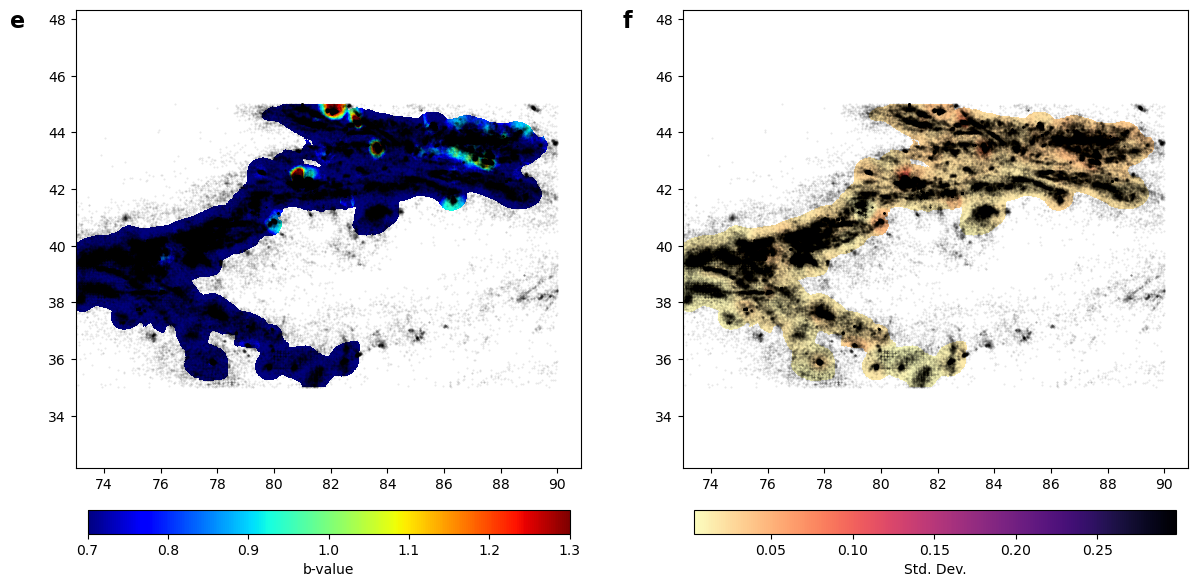

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from seismostats.analysis import ClassicBValueEstimator, BPositiveBValueEstimator


# 二维 b 值扫描函数 (融合版) =================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy

# 假设您已经导入了 ClassicBValueEstimator
# from seismostats.analysis import ClassicBValueEstimator

def spatial_b_value_map_2D(
    lon, 
    lat, 
    mags, 
    grid_size=0.1, 
    n_events=100,      # ZMAP逻辑的核心：目标样本数 N
    max_radius=None,   # 可选：最大搜索半径 (度)，防止连接到几百公里外的地震
    mc=None, 
    delta_m=0.1, 
    b_method=None
):
    """
    【ZMAP 模式】基于最近邻 (Nearest Neighbor) 的移动窗口扫描。
    逻辑：每个网格点强制取最近的 n_events 个地震进行计算。
    """
    # 1. 数据预清洗 (转为 numpy 数组)
    lons_arr = np.array(lon)
    lats_arr = np.array(lat)
    mags_arr = np.array(mags)
    
    valid_mask = ~np.isnan(mags_arr)
    lons_arr = lons_arr[valid_mask]
    lats_arr = lats_arr[valid_mask]
    mags_arr = mags_arr[valid_mask]

    # 2. Mc 筛选
    # ZMAP 逻辑：只对大于 Mc 的“有效地震”进行最近邻搜索
    if mc is not None:
        idx = mags_arr >= (mc - delta_m / 2)
        lons_proc = lons_arr[idx]
        lats_proc = lats_arr[idx]
        mags_proc = mags_arr[idx]
    else:
        lons_proc = lons_arr
        lats_proc = lats_arr
        mags_proc = mags_arr

    total_events = len(mags_proc)
    print(f"筛选后用于扫描的有效事件库: {total_events} 个")
    
    if total_events < n_events:
        print(f"错误：总有效地震数 ({total_events}) 小于目标采样数 ({n_events})，无法计算。")
        return None, None, None, None, None

    # 3. 定义网格 (Grid Nodes)
    x_min, x_max = lons_proc.min(), lons_proc.max()
    y_min, y_max = lats_proc.min(), lats_proc.max()
    
    xi = np.arange(x_min, x_max, grid_size)
    yi = np.arange(y_min, y_max, grid_size)
    X, Y = np.meshgrid(xi, yi)
    
    # 初始化结果矩阵
    B_grid = np.full(X.shape, np.nan)
    Std_grid = np.full(X.shape, np.nan)
    Radius_grid = np.full(X.shape, np.nan) # 新增：记录每个点的搜索半径

    # 初始化估算器
    if b_method is None:
        # 这里请确保 ClassicBValueEstimator 已定义
        # estimator = ClassicBValueEstimator()
        raise ValueError("请传入 b_method 参数 (例如 ClassicBValueEstimator)")
    else:
        estimator = b_method()

    # 4. 空间扫描 (Moving Window)
    print(f"开始 ZMAP 模式扫描... 网格: {X.shape}, 每个点取最近 {n_events} 个事件")
    
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            node_lon = X[i, j]
            node_lat = Y[i, j]
            
            # 计算到所有有效地震的距离平方 (欧氏距离近似)
            # 如果区域很大，建议改为 Haversine
            dists_sq = (lons_proc - node_lon)**2 + (lats_proc - node_lat)**2
            
            # --- ZMAP 核心算法 ---
            # 找到最近的 n_events 个地震的索引
            # argpartition 效率很高，不需要全排序
            nearest_idx_unsorted = np.argpartition(dists_sq, n_events)[:n_events]
            
            # 获取这些地震的距离，找出其中最大的那个作为“分辨率半径”
            current_dists_sq = dists_sq[nearest_idx_unsorted]
            max_dist_sq = np.max(current_dists_sq)
            current_radius_deg = np.sqrt(max_dist_sq)
            
            # 选出的震级
            local_mags = mags_proc[nearest_idx_unsorted]
            
            # --- 额外检查：最大半径限制 ---
            # 如果凑齐 100 个地震需要跑到 500 公里外，这个点的 b 值就没有局部代表性了，设为 NaN
            if max_radius is not None and current_radius_deg > max_radius:
                B_grid[i, j] = np.nan
                continue

            # 计算 b 值
            estimator.calculate(local_mags, mc=mc, delta_m=delta_m)
            
            # 只要 estimator 算出来了，就赋值
            # (通常只要 len(local_mags) > 0 就能算，而这里必定等于 n_events)
            B_grid[i, j] = estimator.b_value
            Std_grid[i, j] = estimator.std
            Radius_grid[i, j] = current_radius_deg

    print("计算完成。")
    return X, Y, B_grid, Std_grid, Radius_grid

# ================= 使用示例 =================

# 设置参数
mc = mc_maxc # chosen magnitude of completeness
delta_m = cat.delta_m # binning of the magnitudes    
N_PER_GRID = 500   
GRID_SIZE = 0.01   
mags = cat.magnitude
print(mags)
longitude = cat.longitude
latitude = cat.latitude


# 执行计算 (假设您已经定义了 ClassicBValueEstimator)
# 如果 ClassicBValueEstimator 在之前的单元格已运行，这里不需要 import
try:
    grid_X, grid_Y, grid_B, grid_Std,grid_R = spatial_b_value_map_2D(
        lon = longitude, 
        lat = latitude,
        mags = mags,
        grid_size=GRID_SIZE, 
        n_events=N_PER_GRID, 
        mc=mc, 
        max_radius=0.5,  # 可选：最大搜索半径 2 度 (~200km)
        delta_m=delta_m,
        b_method=ClassicBValueEstimator # 显式传入方法类
    )

    # 绘图：同时展示 b 值 和 标准差 error
    if grid_B is not None:
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        my_cmap = copy.copy(plt.get_cmap('jet'))
    
        # 2. 【核心步骤】设置 NaN 值的颜色
        # 'white' 表示白色，alpha=0 表示完全透明（如果想透出底图）
        # 如果您没有底图，设为 'white' (alpha=1) 也是可以的
        my_cmap.set_bad(color='white')
        # 图 1: b-value
        im1 = axes[0].pcolormesh(grid_X, grid_Y, grid_B, cmap=my_cmap, shading='auto', vmin=0.7, vmax=1.3)
        plt.colorbar(im1,orientation='horizontal', fraction=0.046, pad=0.08, ax=axes[0], label='b-value')
        # axes[0].set_title(f'Spatial b-value (N={N_PER_GRID})')
        axes[0].scatter(longitude, latitude, s=0.2, c='k', alpha=0.1)
        axes[0].axis('equal')

        # 图 2: Standard Deviation
        # std 通常较小，颜色范围可以自动或设为 0 ~ 0.2
        im2 = axes[1].pcolormesh(grid_X, grid_Y, grid_Std, cmap='magma_r', shading='auto')
        plt.colorbar(im2,orientation='horizontal', fraction=0.046, pad=0.08,ax=axes[1], label='Std. Dev.')
        # axes[1].set_title(f'Standard Deviation of b (N={N_PER_GRID})')
        axes[1].scatter(longitude, latitude, s=0.2, c='k', alpha=0.1)
        axes[1].axis('equal')
        labels = ['e', 'f']

        for i, ax in enumerate(axes.flat):
            ax.text(-0.1, 0.95, labels[i], transform=ax.transAxes,
                fontsize=16, fontweight='bold', va='bottom', ha='right')

        plt.tight_layout()
        plt.subplots_adjust(wspace=0.2, hspace=0.3)
        plt.savefig('1wholeb_value_map.tiff', dpi=300)
        plt.show()

except NameError:
    print("错误: 找不到 ClassicBValueEstimator 类。请确保您已经运行了包含该类定义的代码块。")

## 5.2 导出计算好的数据

In [37]:
# 将数据展平并保存为 CSV (Long, Lat, b_value, Std)
# 过滤掉 NaN 值以便 GMT 处理
data_export = []
for i in range(grid_X.shape[0]):
    for j in range(grid_X.shape[1]):
        if not np.isnan(grid_B[i, j]):
            data_export.append([grid_X[i, j], grid_Y[i, j], grid_B[i, j], grid_Std[i, j]])

df_export = pd.DataFrame(data_export, columns=['lon', 'lat', 'b', 'std'])
df_export.to_csv('b_value_2D.txt', sep='\t', index=False, header=False)
print("数据已导出为 b_value_2D.txt")

数据已导出为 b_value_2D.txt
